# Assignment 5 (29th May)
Joanna Kusy 275999, Tomasz Srebniak 275987

## Problem 5.1: Variational Autoencoder (35 points)
Implement VAE from scratch in PyTorch:

• Train on Fashion-MNIST dataset.

• Implement reparameterization trick correctly.

• Visualize latent space in 2D using t-SNE.

• Generate new samples by sampling from latent distribution.

• Perform latent space interpolation between pairs of images.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.manifold import TSNE

import numpy as np 
import keras as K
from keras.layers import Dense, Flatten
import tensorflow as tf

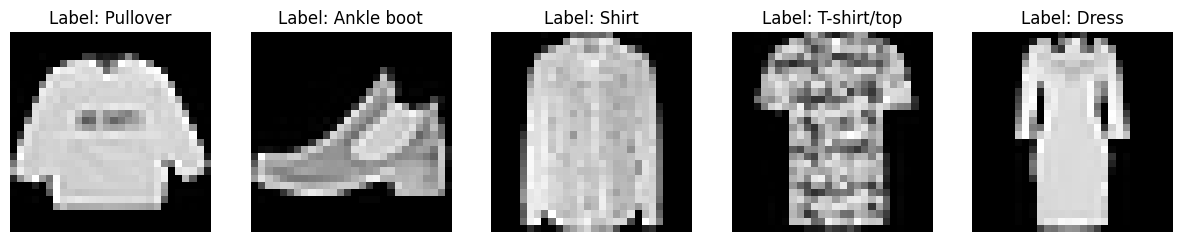

In [40]:
# load fashion mnist dataset from data
train = pd.read_csv('data/fashion-mnist_train.csv')
test = pd.read_csv('data/fashion-mnist_test.csv')

X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values
X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

labels = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

# visualize some examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = train.iloc[i, 1:].values.reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {labels[train.iloc[i, 0]]}')
    axes[i].axis('off')
plt.show()

In [29]:
# Custom VAE model (Keras)
class VAE(K.models.Model):
    def __init__(self, hidden_dim=128, latent_dim=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.flatten = Flatten()
        self.encoder_dense = Dense(hidden_dim, activation='relu')
        self.mu_layer = Dense(latent_dim)
        self.log_var_layer = Dense(latent_dim)
        self.decoder_dense = Dense(hidden_dim, activation='relu')
        self.decoder_out = Dense(784, activation='sigmoid')

    def encode(self, x):
        x = self.flatten(x)
        h = self.encoder_dense(x)
        mu = self.mu_layer(h)
        log_var = self.log_var_layer(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        eps = tf.random.normal(shape=tf.shape(mu))
        sigma = tf.exp(0.5 * log_var)
        return mu + sigma * eps

    def decode(self, z):
        h = self.decoder_dense(z)
        return self.decoder_out(h)

    def call(self, inputs, training=False):
        mu, log_var = self.encode(inputs)
        z = self.reparameterize(mu, log_var)
        recon = self.decode(z)
        return recon, mu, log_var

    def _compute_loss(self, x, recon, mu, log_var):
        x_flat = tf.reshape(x, (-1, 784))
        recon_flat = tf.reshape(recon, (-1, 784))
        # Binary cross-entropy loss for reconstruction
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.nn.sigmoid_cross_entropy_with_logits(labels=x_flat, logits=recon_flat), axis=-1))
        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=-1))
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            recon, mu, log_var = self(x, training=True)
            total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        recon, mu, log_var = self(x, training=False)
        total_loss, recon_loss, kl_loss = self._compute_loss(x, recon, mu, log_var)
        return {"loss": total_loss, "reconstruction_loss": recon_loss, "kl_loss": kl_loss}

# reshape inputs to 28x28
X_train_img = X_train.reshape(-1, 28, 28) / 255.0
X_test_img = X_test.reshape(-1, 28, 28) / 255.0

vae = VAE(hidden_dim=128, latent_dim=2)
vae.compile(optimizer='adam')
# Only pass images (X_train_img), not labels - VAE is unsupervised
history = vae.fit(X_train_img, epochs=50, batch_size=128, validation_data=X_test_img)


Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 3.0322 - loss: 532.7214 - reconstruction_loss: 529.6893 - val_kl_loss: 2.6669 - val_loss: 537.1906 - val_reconstruction_loss: 534.5237
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.6186 - loss: 530.2249 - reconstruction_loss: 527.6063 - val_kl_loss: 2.5647 - val_loss: 531.3782 - val_reconstruction_loss: 528.8136
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.8778 - loss: 524.3041 - reconstruction_loss: 521.4262 - val_kl_loss: 2.4711 - val_loss: 530.5797 - val_reconstruction_loss: 528.1086
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.7529 - loss: 527.6132 - reconstruction_loss: 524.8602 - val_kl_loss: 2.5050 - val_loss: 530.4902 - val_reconstruction_loss: 527.9853
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 2.6965 - loss: 526.3679 - reconstruction_loss: 523.6714 - val_kl_loss: 2.4257 - val_loss: 529.3316 - val_reconstruction_loss: 526.9059
Epoch 6/50

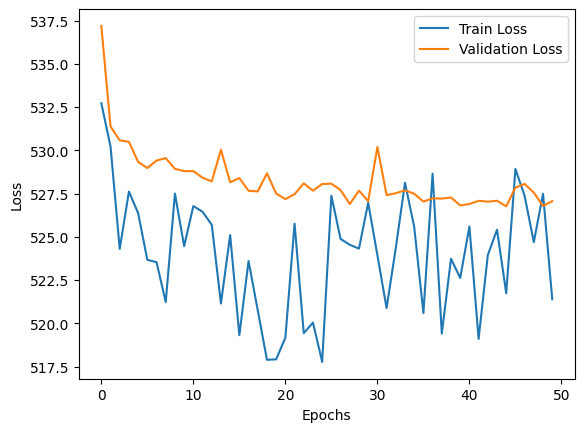

In [34]:
# plot train and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

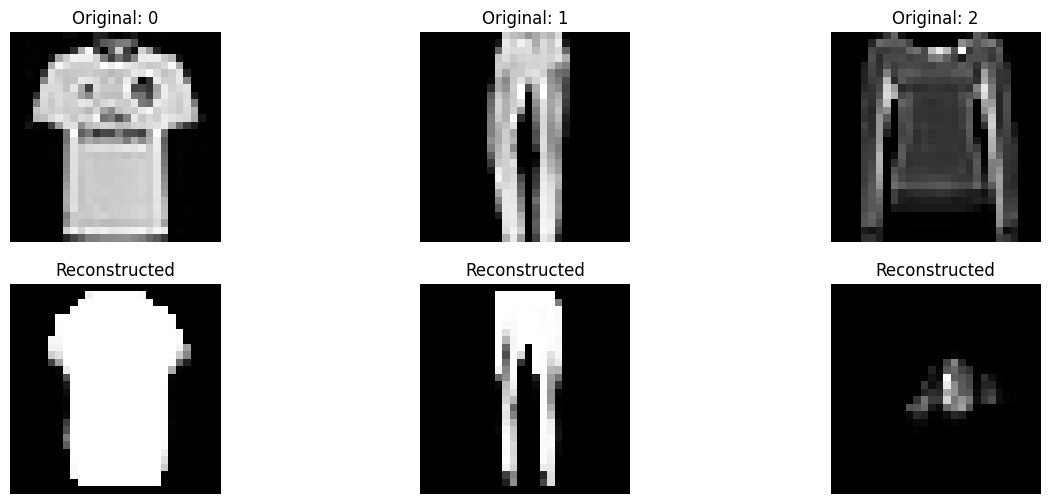

In [38]:
# pass several images from test set through the VAE to get reconstructions and latent variables
recon, mu, log_var = vae(X_test_img[:3])
# plot original and reconstructed images
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i in range(3):
    # Original image
    axes[0, i].imshow(X_test_img[i], cmap='gray')
    axes[0, i].set_title(f'Original: {y_test[i]}')
    axes[0, i].axis('off')
    # Reconstructed image
    recon_img = recon[i].numpy().reshape(28, 28)
    axes[1, i].imshow(recon_img, cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')
plt.show()

The model can reconstruct the shapes of the images which in a distinguishable way, but the details are blurry. This applies only when a high contrast is observed in the image. The reconstruction of blouson is quite poor as it does not have a distinct light shape on the black background.

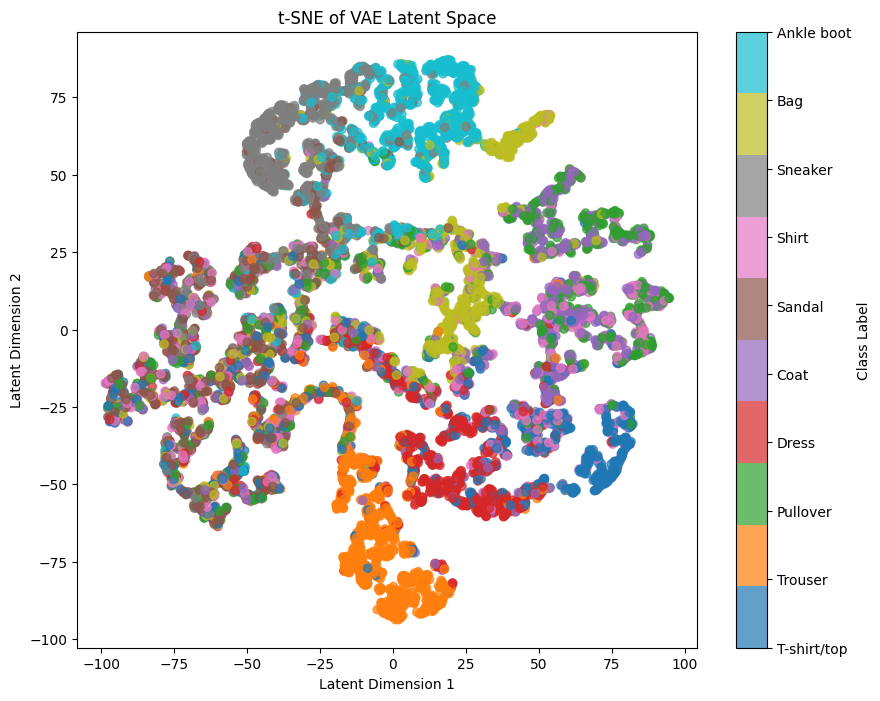

In [46]:
# visualize latent space with t-SNE
mu_test, _, _ = vae(X_test_img)
tsne = TSNE(n_components=2, random_state=42)
mu_2d = tsne.fit_transform(mu_test.numpy())
plt.figure(figsize=(10, 8))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=y_test, cmap='tab10', alpha=0.7)
cbar = plt.colorbar(scatter, ticks=list(labels.keys()), label='Class Label')
cbar.ax.set_yticklabels([labels[k] for k in labels.keys()])
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('t-SNE of VAE Latent Space')
plt.show()

Some of the groups are easily separable in the latent space, while others are more mixed. For example, T-shirt/top and Shirt are quite close to each other, which makes sense as they have similar shapes. On the other hand, Trouser, Sneaker and Ankle boot are more separated from the rest, likely due to their distinct shapes.

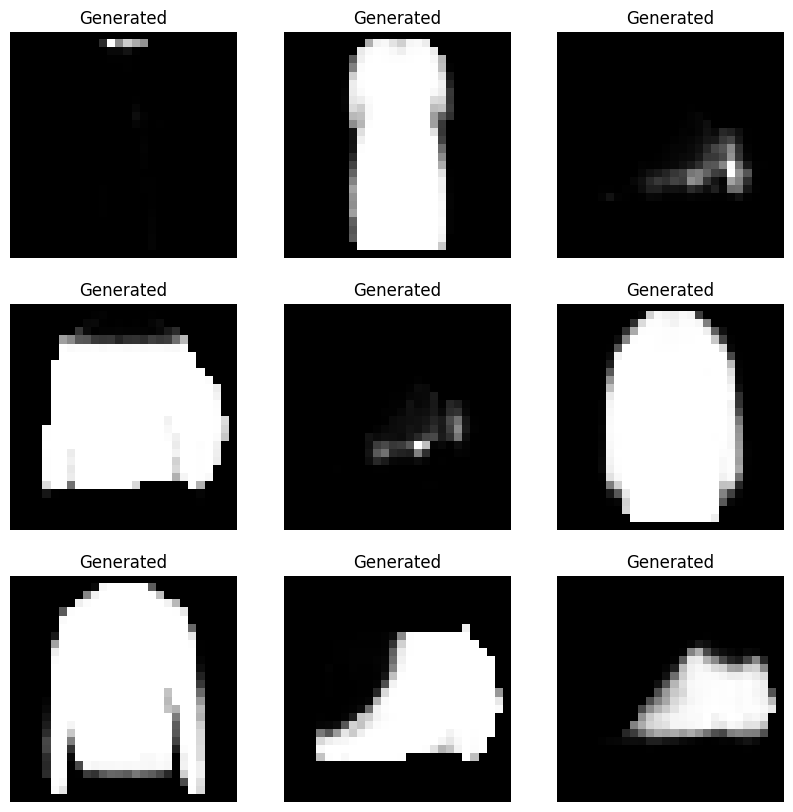

In [50]:
# generate new samples by sampling from the latent space
z_samples = np.random.normal(size=(10, 2))  # Sample 10 random points in the latent space
generated_imgs = vae.decode(z_samples).numpy().reshape(-1, 28, 28)
# plot generated images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    axes[i // 3, i % 3].imshow(generated_imgs[i], cmap='gray')
    axes[i // 3, i % 3].set_title('Generated')
    axes[i // 3, i % 3].axis('off')
plt.show()

Boots, dress, and shirts look sensible but some of the images do not have a clear shape and look like noise. This looks similar to the results obtained e.g. for blouson earlier.

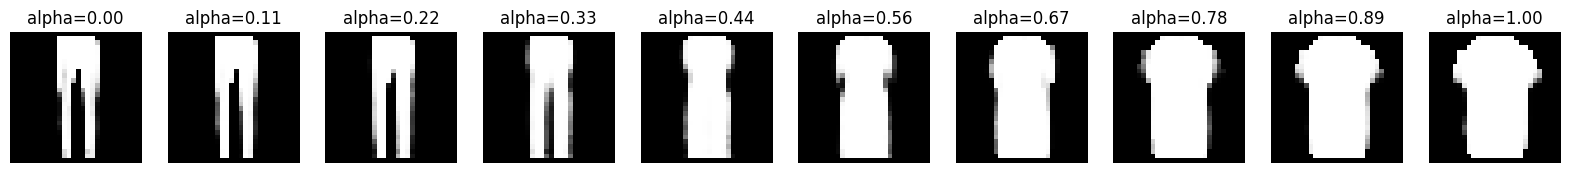

In [66]:
# perform latent space interpolation between pairs of images from test set
img1, img2 = X_test_img[0], X_test_img[1]
mu1, _ = vae.encode(img1[None, ...])
mu2, _ = vae.encode(img2[None, ...])

# Interpolate in latent space
alphas = np.linspace(0, 1, num=10)
interpolated_imgs = []
for alpha in alphas:
    z_interp = alpha * mu1 + (1 - alpha) * mu2
    recon_interp = vae.decode(z_interp).numpy()[0].reshape(28, 28)
    interpolated_imgs.append(recon_interp)

# plot interpolated images
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, img in enumerate(interpolated_imgs):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'alpha={alphas[i]:.2f}')
    axes[i].axis('off')
plt.show()

## Problem 5.2: GAN Implementation (35 points)
Build a DCGAN for image generation:

• Train on CIFAR-10 dataset.

• Implement proper generator and discriminator architectures.

• Monitor training stability using loss curves and Fr´echet Inception Dis-
tance.

• Generate grid of synthetic images throughout training.

• Discuss challenges encountered and solutions applied.

## Problem 5.3: Anomaly Detection with VAE (30 points)
Use VAE for unsupervised anomaly detection:

• Train VAE on normal samples from credit card fraud dataset.

• Use reconstruction error as anomaly score.

• Compare with traditional anomaly detection methods (Isolation Forest,
One-Class SVM).

• Evaluate using precision-recall curves and ROC-AUC.